<a href="https://colab.research.google.com/github/santosoj160/Employee-Data-Cleaning-Preprocessing/blob/main/Data_Cleaning_joko.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Cleaning
### Tolong baca perintah dan tagar komen dengan saksama :)

# Task 1 — Data Understanding & Exploratory Data Analysis (25 poin)

## Instruksi

Lakukan eksplorasi awal terhadap dataset. Minimal yang harus ditampilkan:
1. Dataset Overview
- Shape dataset
- Data type tiap kolom
- Statistik deskriptif

2. Duplicate Check
- Identifikasi jumlah data duplikat
- Lakukan handling yang sesuai

## Dataset Overview

In [33]:
import pandas as pd
import gdown

file_id = "1l1t7L4TD1c5TyxuZ20Bzu3N3mxh4Z1BI"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "employee_data.csv", quiet=False)

df = pd.read_csv(url)

df.head()

Downloading...
From: https://drive.google.com/uc?id=1l1t7L4TD1c5TyxuZ20Bzu3N3mxh4Z1BI
To: /content/employee_data.csv
100%|██████████| 113k/113k [00:00<00:00, 83.1MB/s]


,employee_id,department,job_role,education_level,work_mode,city,age,years_experience,monthly_salary,training_hours,projects_completed,overtime_hours,satisfaction_score,performance_category
0,EMP00001,IT,Sales Executive,High School,Hybrid,Surabaya,23,28,19537826.0,17.0,19,22,2.6,Low
1,EMP00002,IT,Software Engineer,Bachelor,Hybrid,Jakarta,30,32,14951456.0,25.0,19,14,1.2,Low
2,EMP00003,Sales,Product Manager,Bachelor,Remote,Bandung,53,16,20549508.0,49.0,3,2,1.3,Low
3,EMP00004,IT,Software Engineer,High School,Remote,Yogyakarta,23,20,11822392.0,61.0,16,7,3.9,Low
4,EMP00005,IT,Product Manager,Master,Onsite,Jakarta,49,33,NaN,27.0,2,33,5.0,Low


In [34]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1248 entries, 0 to 1247
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           1248 non-null   object 
 1   department            1248 non-null   object 
 2   job_role              1248 non-null   object 
 3   education_level       1143 non-null   object 
 4   work_mode             1248 non-null   object 
 5   city                  1248 non-null   object 
 6   age                   1248 non-null   int64  
 7   years_experience      1248 non-null   int64  
 8   monthly_salary        1149 non-null   float64
 9   training_hours        1149 non-null   float64
 10  projects_completed    1248 non-null   int64  
 11  overtime_hours        1248 non-null   int64  
 12  satisfaction_score    1149 non-null   float64
 13  performance_category  1248 non-null   object 
dtypes: float64(3), int64(4), object(7)
memory usage: 136.6+ KB


,age,years_experience,monthly_salary,training_hours,projects_completed,overtime_hours,satisfaction_score
count,1248.000000,1248.000000,1.149000e+03,1149.000000,1248.000000,1248.000000,1149.000000
mean,40.067308,17.283654,1.887583e+07,41.112272,9.797276,20.328526,3.043864
std,12.285443,9.814951,1.633824e+07,41.115442,5.733993,20.100974,1.144541
min,21.000000,0.000000,5.000706e+06,0.000000,0.000000,0.000000,1.000000
25%,30.000000,9.000000,1.168406e+07,18.000000,5.000000,9.000000,2.100000
50%,40.000000,18.000000,1.795159e+07,38.000000,10.000000,19.000000,3.000000
75%,49.000000,26.000000,2.377860e+07,59.000000,15.000000,30.000000,4.000000
max,120.000000,34.000000,2.500000e+08,500.000000,19.000000,250.000000,5.000000


## Distribusi Data

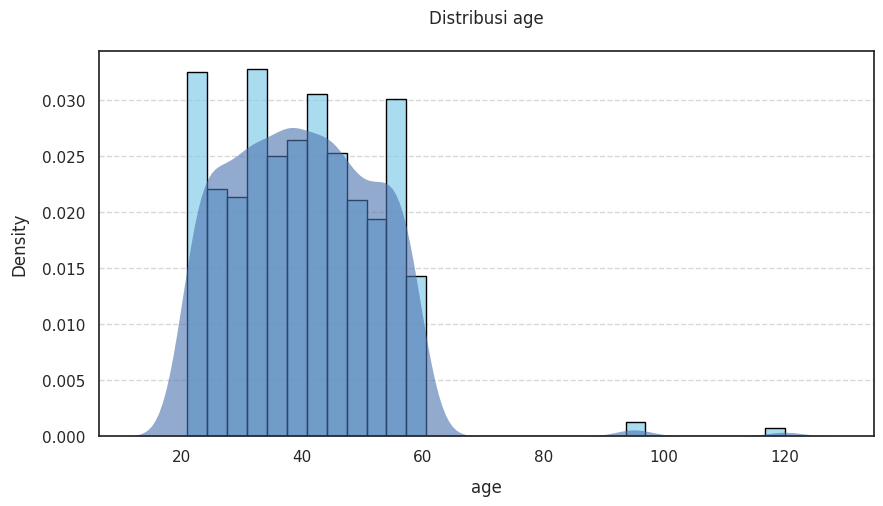


--------------------------------------------------------------------------------



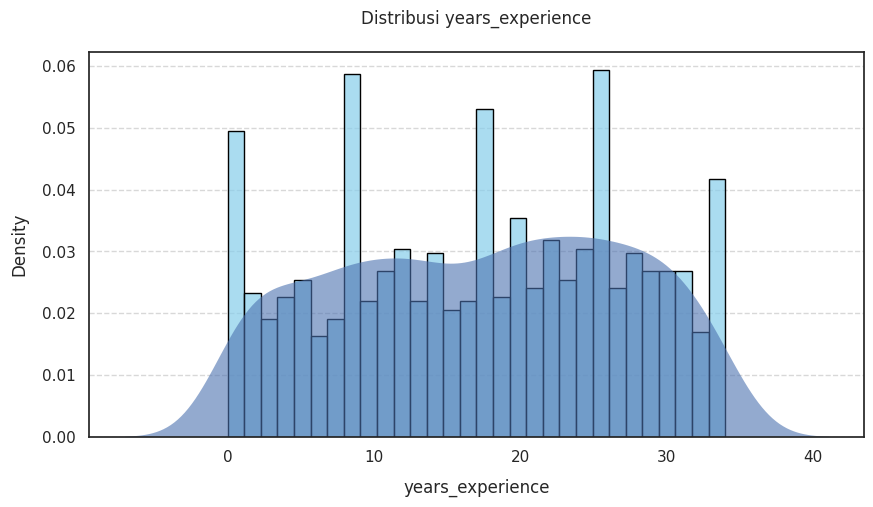


--------------------------------------------------------------------------------



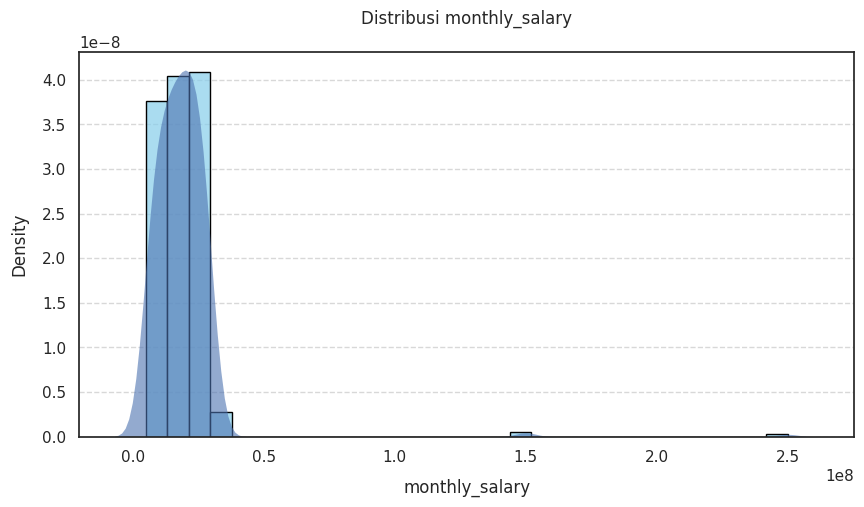


--------------------------------------------------------------------------------



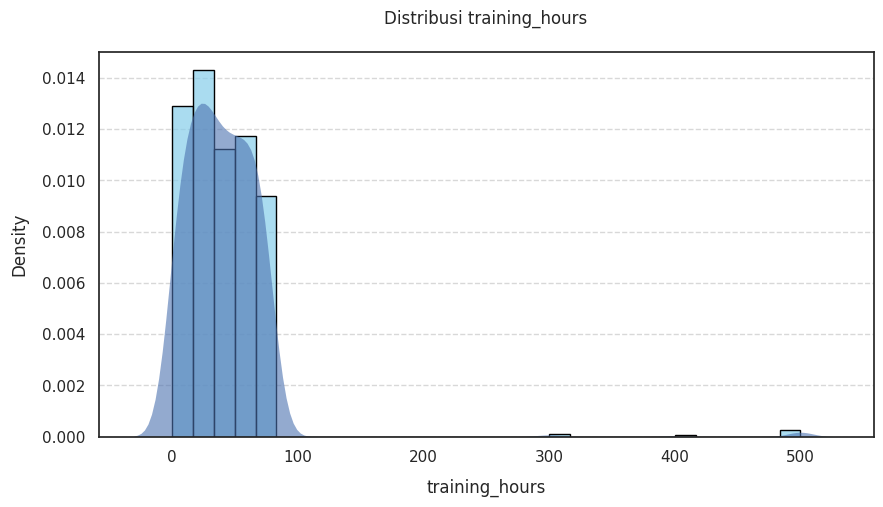


--------------------------------------------------------------------------------



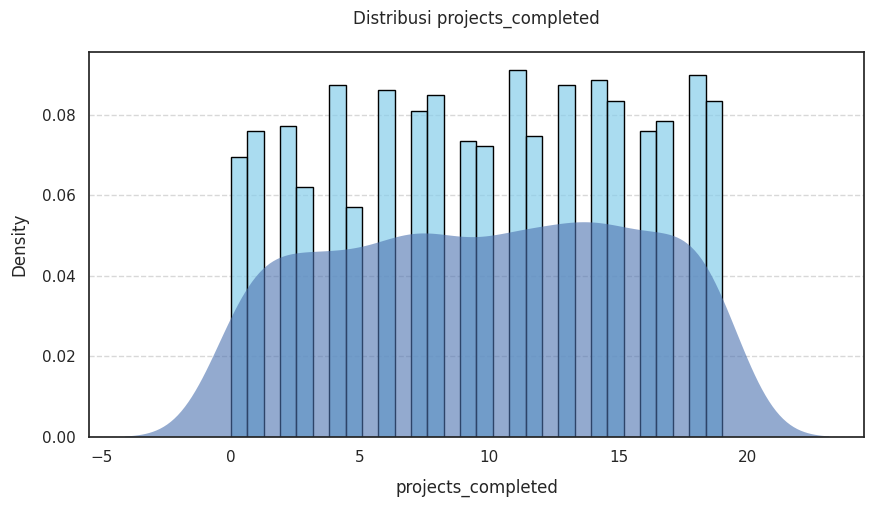


--------------------------------------------------------------------------------



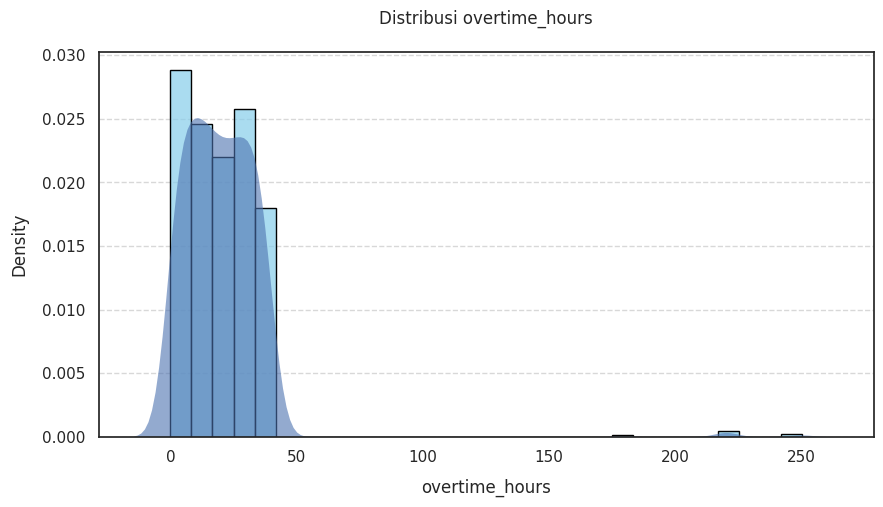


--------------------------------------------------------------------------------



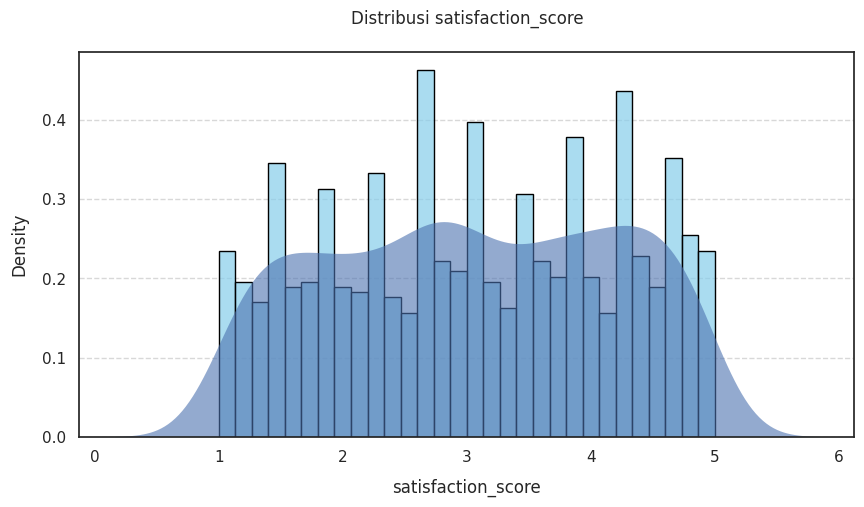


--------------------------------------------------------------------------------



In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="white")

num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure(figsize=(10,5))

    # pke hisplot untk bar dgn density
    sns.histplot(df[col], bins=30, color='skyblue', stat='density', alpha=0.7, edgecolor='black')

    # Overlay a filled KDE plot to show density with a color gradient, similar to a heatmap
    sns.kdeplot(df[col], fill=True, cmap='viridis', alpha=0.6, linewidth=0)

    plt.title(f"Distribusi {col}", pad=20)
    plt.xlabel(col, labelpad=10)
    plt.ylabel("Density", labelpad=10) # Changed ylabel to Density
    plt.grid(axis='y', alpha=0.75, linestyle='--') # Added a grid for better readability

    plt.show()
    plt.close()

    print("\n" + "-"*80 + "\n")

## Duplicate Check

In [36]:
# jumlah duplikat
print("Jumlah duplicate:", df.duplicated().sum())

# hapus duplicate
df = df.drop_duplicates()

print("Setelah drop duplicate:", df.duplicated().sum())

Jumlah duplicate: 43
Setelah drop duplicate: 0


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1205 entries, 0 to 1237
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           1205 non-null   object 
 1   department            1205 non-null   object 
 2   job_role              1205 non-null   object 
 3   education_level       1107 non-null   object 
 4   work_mode             1205 non-null   object 
 5   city                  1205 non-null   object 
 6   age                   1205 non-null   int64  
 7   years_experience      1205 non-null   int64  
 8   monthly_salary        1108 non-null   float64
 9   training_hours        1109 non-null   float64
 10  projects_completed    1205 non-null   int64  
 11  overtime_hours        1205 non-null   int64  
 12  satisfaction_score    1108 non-null   float64
 13  performance_category  1205 non-null   object 
dtypes: float64(3), int64(4), object(7)
memory usage: 141.2+ KB


In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df.select_dtypes(include='object').columns

Index(['employee_id', 'department', 'job_role', 'education_level', 'work_mode',
       'city', 'performance_category'],
      dtype='object')

In [40]:
for col in df.select_dtypes(include='object').columns:
    print("\n", col)
    print(df[col].value_counts())


 employee_id
employee_id
EMP00440    2
EMP00571    2
EMP00071    2
EMP00045    2
EMP00677    2
           ..
EMP00399    1
EMP00398    1
EMP00397    1
EMP00396    1
EMP00405    1
Name: count, Length: 1200, dtype: int64

 department
department
HR            221
Operations    218
Sales         195
Finance       185
Marketing     185
IT            181
it             20
Name: count, dtype: int64

 job_role
job_role
Product Manager         146
Customer Success        126
Data Engineer           124
Business Analyst        122
Marketing Specialist    119
Software Engineer       118
Data Analyst            118
HR Officer              115
Sales Executive         109
Finance Analyst         108
Name: count, dtype: int64

 education_level
education_level
High School    306
Bachelor       272
Master         268
Diploma        261
Name: count, dtype: int64

 work_mode
work_mode
Onsite    405
Hybrid    400
Remote    400
Name: count, dtype: int64

 city
city
Surabaya      216
Semarang      198
Jaka

In [41]:
df["department"] = df["department"].replace("it", "IT")


In [42]:
df["department"].value_counts()

,count
department,
HR,221
Operations,218
IT,201
Sales,195
Marketing,185
Finance,185


In [43]:
df["city"] = df["city"].str.strip().str.lower()
df["city"] = df["city"].replace("jakarta", "Jakarta")

In [44]:
df["city"].value_counts()

,count
city,
surabaya,216
Jakarta,216
semarang,198
bandung,196
medan,192
yogyakarta,187


## Insight

Berikan minimal:
- 3 insight dari kolom numerik
- 3 insight dari kolom kategorikal

**Insight Kolom Numerik**

**Age**

Sebagian besar karyawan usianya ada di kisaran 20 sampai 60 tahun. Tapi ada beberapa data yang aneh, seperti usia di atas 90 bahkan sampai 120 tahun, ini kemungkinan outlier dan perlu dicek lagi.

**Monthly Salary**

Gaji bulanan terlihat tidak merata. Mayoritas karyawan ada di gaji rendah sampai menengah, tapi ada beberapa yang sangat tinggi. Ini bikin distribusinya miring ke kanan (right skewed), jadi kemungkinan ada outlier.

**Training Hours**

Sebagian besar karyawan punya jam training yang rendah. Tapi ada juga beberapa yang sangat tinggi sampai ratusan jam. Ini juga terlihat tidak normal dan kemungkinan outlier.


**Insight Kolom Kategorikal**

**Department**

Distribusi department cukup merata di beberapa divisi. HR dan Operations sedikit lebih banyak dibanding divisi lainnya, tapi secara keseluruhan masih seimbang.

**Education Level**

Sebagian besar karyawan lulusan High School, diikuti Bachelor dan Master. Diploma juga cukup banyak, jadi tingkat pendidikan karyawan cukup beragam.

**Work Mode**

Pembagian work mode cukup seimbang antara onsite, hybrid, dan remote. Onsite sedikit lebih banyak, tapi selisihnya tidak terlalu besar, jadi fleksibilitas kerja masih cukup tinggi.

# Task 2 — Outlier Analysis & Handling (25 poin)

## Instruksi

Lakukan analisis outlier menggunakan metode IQR.
Untuk setiap kolom numerik:
1. Hitung
```
Q1
Q3
IQR
Lower Bound
Upper Bound
```

2. Identifikasi jumlah outlier
3. Lakukan handling outlier menggunakan metode yang menurut Anda paling sesuai: Winsorization

In [45]:
# Mengambil semua kolom numerik dari dataset
import numpy as np

num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols

Index(['age', 'years_experience', 'monthly_salary', 'training_hours',
       'projects_completed', 'overtime_hours', 'satisfaction_score'],
      dtype='object')

In [46]:
# Loop untuk semua kolom numerik
for col in num_cols:

    # Menghitung Q1 (kuartil 1) dan Q3 (kuartil 3)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Menghitung Interquartile Range (IQR)
    IQR = Q3 - Q1

    # Menentukan batas bawah dan batas atas
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Mengidentifikasi data outlier
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    jumlah_outlier = len(outliers)

    # Menampilkan hasil analisis outlier
    print(f"\nKolom: {col}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")
    print(f"Jumlah Outlier: {jumlah_outlier}")

    # Handling outlier menggunakan metode Winsorization (capping)
    df[col] = np.where(df[col] < lower_bound, lower_bound,
                np.where(df[col] > upper_bound, upper_bound, df[col]))


Kolom: age
Q1: 30.0
Q3: 49.0
IQR: 19.0
Lower Bound: 1.5
Upper Bound: 77.5
Jumlah Outlier: 8

Kolom: years_experience
Q1: 9.0
Q3: 26.0
IQR: 17.0
Lower Bound: -16.5
Upper Bound: 51.5
Jumlah Outlier: 0

Kolom: monthly_salary
Q1: 11757582.5
Q3: 23795654.0
IQR: 12038071.5
Lower Bound: -6299524.75
Upper Bound: 41852761.25
Jumlah Outlier: 8

Kolom: training_hours
Q1: 18.0
Q3: 59.0
IQR: 41.0
Lower Bound: -43.5
Upper Bound: 120.5
Jumlah Outlier: 8

Kolom: projects_completed
Q1: 5.0
Q3: 15.0
IQR: 10.0
Lower Bound: -10.0
Upper Bound: 30.0
Jumlah Outlier: 0

Kolom: overtime_hours
Q1: 9.0
Q3: 30.0
IQR: 21.0
Lower Bound: -22.5
Upper Bound: 61.5
Jumlah Outlier: 8

Kolom: satisfaction_score
Q1: 2.1
Q3: 4.0
IQR: 1.9
Lower Bound: -0.7499999999999996
Upper Bound: 6.85
Jumlah Outlier: 0


### Ringkasan Analisis Outlier (Tabel Interaktif)

In [47]:
# Membuat ringkasan hasil analisis outlier dalam bentuk DataFrame

outlier_summary_data = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Outlier dihitung dari DataFrame awal sebelum capping diterapkan
    # Jika ingin melihat outlier setelah capping, df yang digunakan harus yang sudah di-capping
    # Namun, umumnya analisis outlier dilakukan sebelum handling
    initial_df = pd.read_csv(url) # Reload df to get original values for outlier count
    outliers = initial_df[(initial_df[col] < lower_bound) | (initial_df[col] > upper_bound)]
    jumlah_outlier = len(outliers)

    outlier_summary_data.append({
        "Kolom": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Batas Bawah": lower_bound,
        "Batas Atas": upper_bound,
        "Jumlah Outlier": jumlah_outlier
    })

df_outlier_summary = pd.DataFrame(outlier_summary_data)

# Menampilkan tabel interaktif dengan conditional formatting dan background header
display(df_outlier_summary.style \
    .background_gradient(cmap='YlOrRd', subset=['Jumlah Outlier']))

,Kolom,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jumlah Outlier
0,age,30.000000,49.000000,19.000000,1.500000,77.500000,8
1,years_experience,9.000000,26.000000,17.000000,-16.500000,51.500000,0
2,monthly_salary,11757582.500000,23795654.000000,12038071.500000,-6299524.750000,41852761.250000,8
3,training_hours,18.000000,59.000000,41.000000,-43.500000,120.500000,8
4,projects_completed,5.000000,15.000000,10.000000,-10.000000,30.000000,0
5,overtime_hours,9.000000,30.000000,21.000000,-22.500000,61.500000,8
6,satisfaction_score,2.100000,4.000000,1.900000,-0.750000,6.850000,0



### Ringkasan Distribusi Data Numerik (Sebelum Penanganan Outlier)

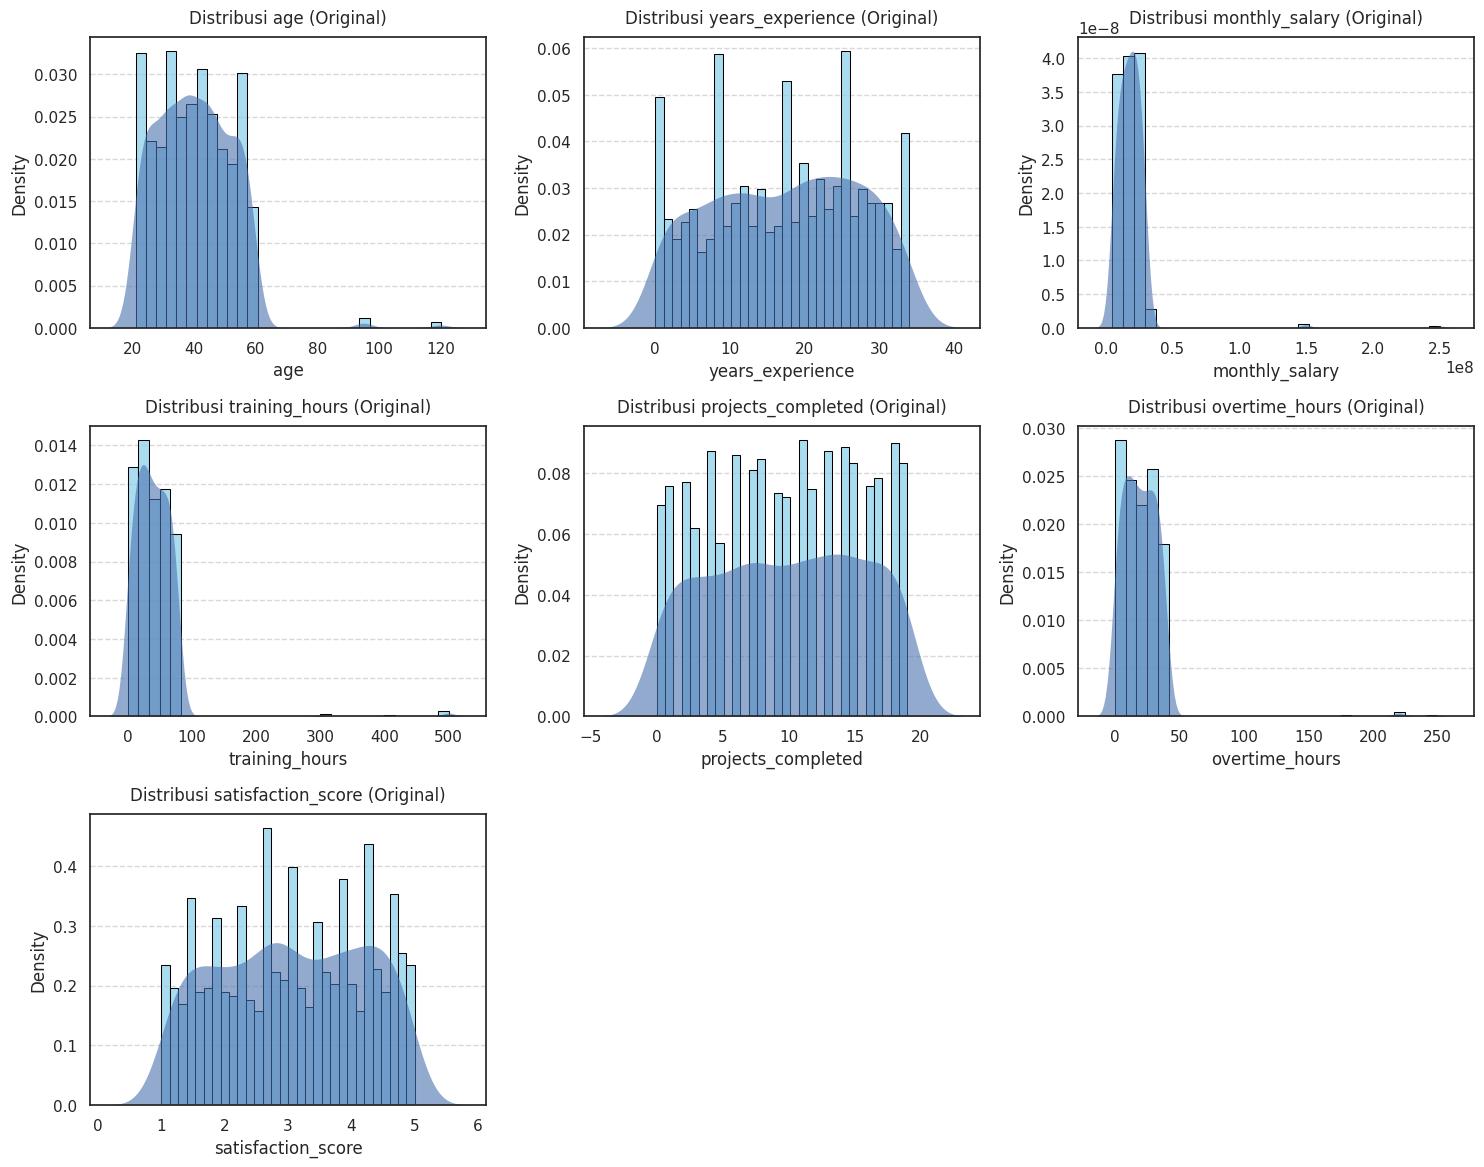

In [48]:
import math
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set(style="white")

# Muat ulang DataFrame asli untuk melihat distribusi sebelum capping
df_original = pd.read_csv(url)

# Dapatkan kolom numerik dari DataFrame asli
num_cols_original = df_original.select_dtypes(include=['int64', 'float64']).columns

# Tentukan jumlah baris dan kolom untuk subplots
num_plots_original = len(num_cols_original)
num_cols_grid_original = 3 # Misalnya, 3 kolom per baris
num_rows_grid_original = math.ceil(num_plots_original / num_cols_grid_original)

plt.figure(figsize=(num_cols_grid_original * 5, num_rows_grid_original * 4))

for i, col in enumerate(num_cols_original):
    plt.subplot(num_rows_grid_original, num_cols_grid_original, i + 1)

    # Histogram dengan density
    sns.histplot(df_original[col], bins=30, color='skyblue', stat='density', alpha=0.7, edgecolor='black')

    # Overlay KDE plot yang terisi dengan gradien warna
    sns.kdeplot(df_original[col], fill=True, cmap='viridis', alpha=0.6, linewidth=0)

    plt.title(f"Distribusi {col} (Original)", pad=10)
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.grid(axis='y', alpha=0.75, linestyle='--')

plt.tight_layout()
plt.show()
plt.close()

### Ringkasan Distribusi Data Numerik (Setelah Penanganan Outlier)

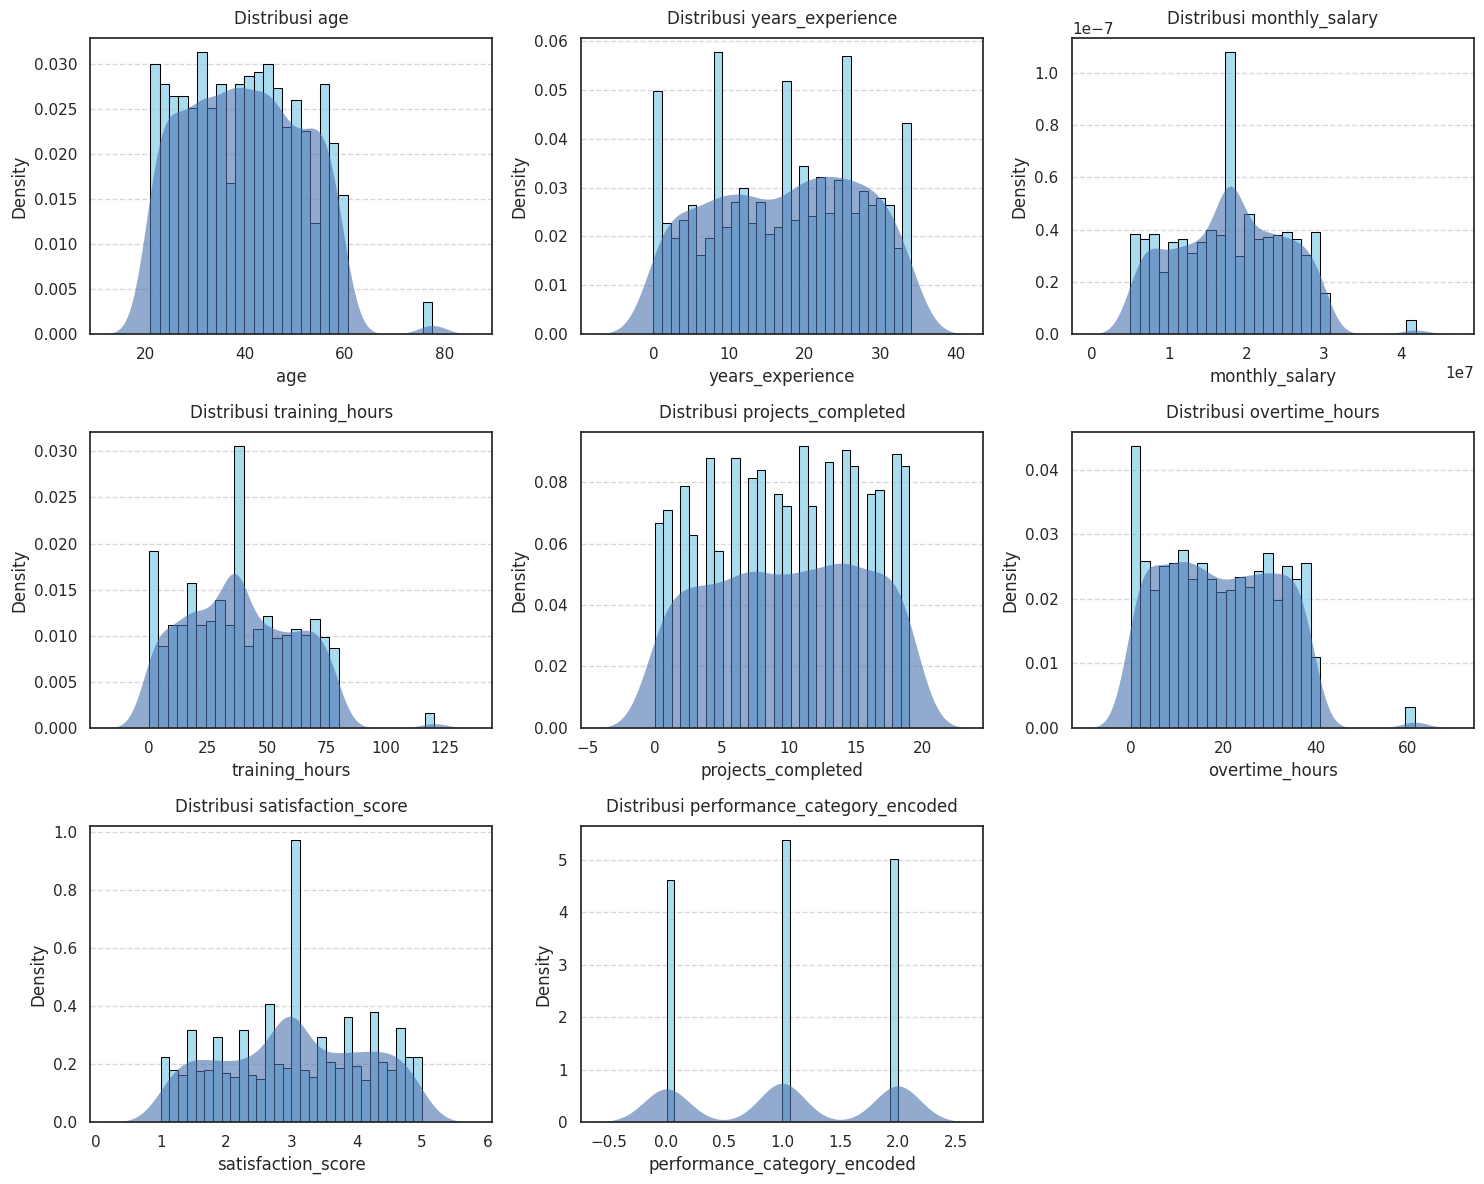

In [60]:
import math
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="white")

# Dapatkan kolom numerik dari DataFrame saat ini
num_cols_current = df.select_dtypes(include=['int64', 'float64']).columns

# Tentukan jumlah baris dan kolom untuk subplots
num_plots = len(num_cols_current)
num_cols_grid = 3 # Misalnya, 3 kolom per baris
num_rows_grid = math.ceil(num_plots / num_cols_grid)

plt.figure(figsize=(num_cols_grid * 5, num_rows_grid * 4)) # Sesuaikan ukuran figure

for i, col in enumerate(num_cols_current):
    plt.subplot(num_rows_grid, num_cols_grid, i + 1)

    # Histogram dengan density
    sns.histplot(df[col], bins=30, color='skyblue', stat='density', alpha=0.7, edgecolor='black')

    # Overlay KDE plot yang terisi dengan gradien warna
    sns.kdeplot(df[col], fill=True, cmap='viridis', alpha=0.6, linewidth=0)

    plt.title(f"Distribusi {col}", pad=10)
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.grid(axis='y', alpha=0.75, linestyle='--')

plt.tight_layout() # Sesuaikan layout agar tidak tumpang tindih
plt.show()
plt.close()

# Task 3 — Missing Value Analysis & Handling (25 poin)

# Instruksi

Lakukan investigasi missing value.

Missing Value Analysis

1. Tampilkan:

`df.isnull().sum()` dan persentase missing value.

2. Handling Missing Value
Gunakan metode yang sesuai:
- Numerical
Contoh: Median
- Categorical
Contoh: Mode

Jelaskan alasan pemilihan metode.

In [50]:
# ngecek jumlah missing value per kolom
missing_count = df.isnull().sum()

# ngitung persen missing value
missing_percent = (df.isnull().sum() / len(df)) * 100

# gabungne hasil neng tabel
missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percent (%)": missing_percent
})

# nmpilne hanya kolom yang ada missing value
missing_df[missing_df["Missing Count"] > 0].sort_values(by="Missing Percent (%)", ascending=False)

,Missing Count,Missing Percent (%)
education_level,98,8.132780
monthly_salary,97,8.049793
satisfaction_score,97,8.049793
training_hours,96,7.966805


In [51]:
# Handling missing value berdasarkan tipe data

for col in df.columns:

    # Jika kolom numerik → gunakan median
    if df[col].dtype in ['int64', 'float64']:
        df[col].fillna(df[col].median(), inplace=True)

    # Jika kolom kategorikal → gunakan mode
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_567/4217826046.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_567/4217826046.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

# Median
digunakan untuk data numerik karena lebih tahan terhadap outlier
# Mode
digunakan untuk data kategorikal karena mewakili nilai yang paling sering muncul
# Metode ini menjaga distribusi data tetap stabil tanpa mengubah karakteristik utama dataset

In [52]:
# mastikne gak ada missing value tersisa
df.isnull().sum()

,0
employee_id,0
department,0
job_role,0
education_level,0
work_mode,0
city,0
age,0
years_experience,0
monthly_salary,0
training_hours,0


# Task 4 — Data Encoding (25 poin)

# Instruksi

Ubah data kategorikal menjadi format numerik yang dapat digunakan untuk analisis lebih lanjut.

A. Label Encoding
1. Lakukan Label Encoding pada kolom: `performance_category`
2. Tampilkan:
- Penjelasan terkait mapping yang digunakan
- Hasil sebelum dan sesudah encoding

B. One Hot Encoding
1. Pilih minimal 2 kolom kategorikal dari daftar berikut:
* department
* work_mode
* city
* education_level
Lakukan One Hot Encoding pada kolom yang dipilih.
2. Tampilkan:
- Kolom sebelum encoding
- Kolom hasil encoding
- Jumlah kolom yang bertambah setelah encoding

In [53]:
# Import Label Encoder
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Menampilkan data sebelum encoding
print("=== SEBELUM ENCODING ===")
print(df["performance_category"].head())

=== SEBELUM ENCODING ===
0    Low
1    Low
2    Low
3    Low
4    Low
Name: performance_category, dtype: object


In [54]:
# Melakukan Label Encoding pada performance_category
df["performance_category_encoded"] = le.fit_transform(df["performance_category"])

# Menampilkan mapping hasil encoding
print("\n=== MAPPING LABEL ENCODING ===")
for i, class_ in enumerate(le.classes_):
    print(f"{class_} -> {i}")


=== MAPPING LABEL ENCODING ===
High -> 0
Low -> 1
Medium -> 2


In [62]:
# Menampilkan hasil setelah encoding
print("\n=== SESUDAH ENCODING ===")
df[["performance_category", "performance_category_encoded"]].head()


=== SESUDAH ENCODING ===


,performance_category,performance_category_encoded
0,Low,1
1,Low,1
2,Low,1
3,Low,1
4,Low,1


# Insight Label Encoding
- Label encoding mengubah kategori menjadi angka agar bisa digunakan dalam model machine learning
- Mapping dilakukan berdasarkan urutan alfabet (default sklearn)
- Cocok untuk target variable seperti performance category


B. One Hot Encoding

Kolom yang dipilih:
1. department
2. work_mode

In [56]:
# Menyimpan kolom sebelum encoding
print("Kolom sebelum encoding:")
print(df[["department", "work_mode"]].head())

Kolom sebelum encoding:
  department work_mode
0         IT    Hybrid
1         IT    Hybrid
2      Sales    Remote
3         IT    Remote
4         IT    Onsite


In [57]:
# Menyimpan jumlah kolom sebelum encoding
before_shape = df.shape

# One Hot Encoding
df_encoded = pd.get_dummies(df, columns=["department", "work_mode"], drop_first=True)

# Menyimpan dataset baru
df = df_encoded

# Menyimpan jumlah kolom setelah encoding
after_shape = df.shape

print("\nShape sebelum encoding:", before_shape)
print("Shape setelah encoding:", after_shape)
print("Jumlah kolom bertambah:", after_shape[1] - before_shape[1])


Shape sebelum encoding: (1205, 15)
Shape setelah encoding: (1205, 20)
Jumlah kolom bertambah: 5


In [58]:
# Menampilkan hasil encoding
df.head()

,employee_id,job_role,education_level,city,age,years_experience,monthly_salary,training_hours,projects_completed,overtime_hours,satisfaction_score,performance_category,performance_category_encoded,department_HR,department_IT,department_Marketing,department_Operations,department_Sales,work_mode_Onsite,work_mode_Remote
0,EMP00001,Sales Executive,High School,surabaya,23.0,28.0,19537826.0,17.0,19.0,22.0,2.6,Low,1,False,True,False,False,False,False,False
1,EMP00002,Software Engineer,Bachelor,Jakarta,30.0,32.0,14951456.0,25.0,19.0,14.0,1.2,Low,1,False,True,False,False,False,False,False
2,EMP00003,Product Manager,Bachelor,bandung,53.0,16.0,20549508.0,49.0,3.0,2.0,1.3,Low,1,False,False,False,False,True,False,True
3,EMP00004,Software Engineer,High School,yogyakarta,23.0,20.0,11822392.0,61.0,16.0,7.0,3.9,Low,1,False,True,False,False,False,False,True
4,EMP00005,Product Manager,Master,Jakarta,49.0,33.0,17938913.0,27.0,2.0,33.0,5.0,Low,1,False,True,False,False,False,True,False


# Insight
- One Hot Encoding digunakan untuk mengubah data kategorikal menjadi numerik tanpa memberikan urutan
- Cocok untuk variabel seperti department dan work mode
- drop_first=True digunakan untuk menghindari dummy variable trap




In [64]:
import pandas as pd
import numpy as np

# 1. Ambil data sebelum encoding langsung dari dataset asal
df_raw = pd.read_csv("employee_data.csv")
df_before = df_raw[['department', 'work_mode', 'performance_category']].head(5)

# 2. Proses encoding untuk sampel 5 data teratas
perf_map = {'High': 0, 'Low': 1, 'Medium': 2}
df_after_label = df_before[['performance_category']].copy()
df_after_label['performance_category_encoded'] = df_after_label['performance_category'].map(perf_map)

# One-Hot Encoding pada department & work_mode
df_after_ohe = pd.get_dummies(df_before[['department', 'work_mode']], drop_first=True)

# Gabungkan hasil sesudah encoding
df_after = pd.concat([df_after_label[['performance_category_encoded']], df_after_ohe], axis=1)

# 3. Tampilkan Tabel SEBELUM Encoding (Highlight Warna Merah Muda/Ungu)
print("=== SEBELUM FEATURE ENCODING (Categorical Text Data) ===")
display(df_before.style\
    .set_caption("Tabel Data Kategorikal Teks")\
    .background_gradient(cmap="PuRd")\
    .set_properties(**{'text-align': 'center'}))

print("\n" + "="*60 + "\n")

# 4. Tampilkan Tabel SESUDAH Encoding (Highlight Warna Hijau)
print("=== SESUDAH FEATURE ENCODING (Full Numerical Data) ===")
display(df_after.style\
    .set_caption("Tabel Hasil Label & One-Hot Encoding")\
    .background_gradient(cmap="YlGn")\
    .set_properties(**{'text-align': 'center'}))

=== SEBELUM FEATURE ENCODING (Categorical Text Data) ===


,department,work_mode,performance_category
0,IT,Hybrid,Low
1,IT,Hybrid,Low
2,Sales,Remote,Low
3,IT,Remote,Low
4,IT,Onsite,Low




=== SESUDAH FEATURE ENCODING (Full Numerical Data) ===


,performance_category_encoded,department_Sales,work_mode_Onsite,work_mode_Remote
0,1,False,False,False
1,1,False,False,False
2,1,True,False,True
3,1,False,False,True
4,1,False,True,False
